<a href="https://colab.research.google.com/github/hasnathvb/ict_assignments/blob/main/casestudy1_hasnath.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/athlete_events - medal.csv')
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992.0,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012.0,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920.0,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988.0,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246859,123601,Nataliya Andreyevna Ustinova,F,19.0,165.0,58.0,Soviet Union,URS,1964 Summer,1964.0,Summer,Tokyo,Swimming,Swimming Women's 4 x 100 metres Medley Relay,Bronze
246860,123601,Nataliya Andreyevna Ustinova,F,23.0,165.0,58.0,Soviet Union,URS,1968 Summer,1968.0,Summer,Mexico City,Swimming,Swimming Women's 100 metres Freestyle,NaN
246861,123601,Nataliya Andreyevna Ustinova,F,23.0,165.0,58.0,Soviet Union,URS,1968 Summer,1968.0,Summer,Mexico City,Swimming,Swimming Women's 4 x 100 metres Freestyle Relay,NaN
246862,123602,Tetiana Illivna Ustiuzhanina,F,27.0,185.0,78.0,Unified Team,EUN,1992 Summer,1992.0,Summer,Barcelona,Rowing,Rowing Women's Quadruple Sculls,Bronze


PART 1 - Data understanding

Q1. Load the dataset

In [3]:
df.head()  #first 5 rows

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992.0,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012.0,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920.0,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988.0,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [4]:
df.shape # number of columns and rows

(246864, 15)

In [5]:
print(df.columns)

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')


Q2. Check data types

In [6]:
df.dtypes

,0
ID,int64
Name,object
Sex,object
Age,float64
Height,float64
Weight,float64
Team,object
NOC,object
Games,object
Year,float64


In [7]:
num = df.select_dtypes(include=['int64','float64']).columns
print("numerical columns:")
print(num)

numerical columns:
Index(['ID', 'Age', 'Height', 'Weight', 'Year'], dtype='object')


In [8]:
cat = df.select_dtypes(include=['object','category']).columns
print("categorical columns:")
print(cat)

categorical columns:
Index(['Name', 'Sex', 'Team', 'NOC', 'Games', 'Season', 'City', 'Sport',
       'Event', 'Medal'],
      dtype='object')


Q3.Missing values

In [9]:
df.isnull().sum()

,0
ID,0
Name,0
Sex,0
Age,8667
Height,54813
Weight,57347
Team,0
NOC,0
Games,0
Year,1


In [11]:
df['Medal'].unique()

array([nan, 'Gold', 'Bronze', 'Silver'], dtype=object)

PART 2 - Medal filtering

Q4.Create a new DataFrame containing only medal winners

In [15]:
Medal_winners_df = df.dropna(subset=['Medal'])

In [16]:
display(Medal_winners_df.head())

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
37,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920.0,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
38,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920.0,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014.0,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948.0,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze


PART 3- Country analysis

Q5.Total Medal Count

In [19]:
top_10_countries = (
    Medal_winners_df.groupby('NOC')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print(top_10_countries)

NOC
USA    5161
URS    2271
GBR    1904
GER    1883
FRA    1714
ITA    1530
SWE    1433
CAN    1239
AUS    1219
HUN    1048
dtype: int64


Q6.Visualize top 10 countries

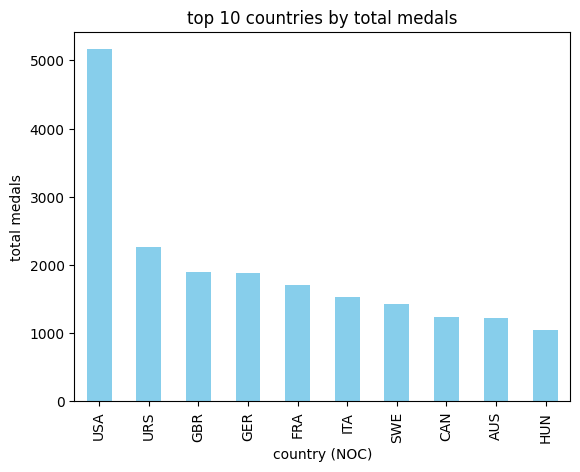

In [20]:
top_10_countries.plot(kind='bar',color='skyblue')
plt.title('top 10 countries by total medals')
plt.xlabel('country (NOC)')
plt.ylabel('total medals')
plt.show()


Q7.Gold medal analysis

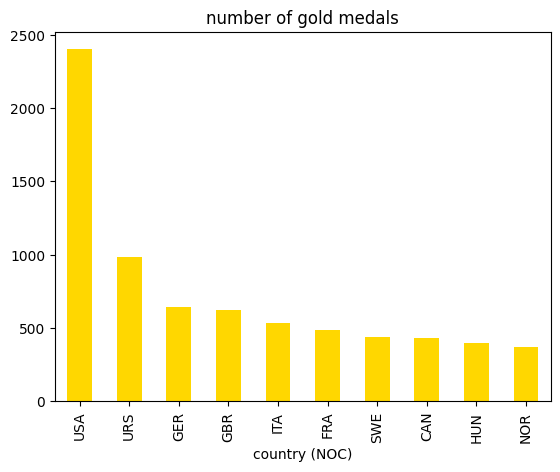

In [25]:
gold = Medal_winners_df[Medal_winners_df['Medal'] == 'Gold']
top_gold = gold['NOC'].value_counts().head(10)
top_gold.plot(kind='bar',color='gold')
plt.title('top 10 countries by gold medals')
plt.xlabel('country (NOC)')
plt.title('number of gold medals')
plt.show()

Q8.Gender Distribution

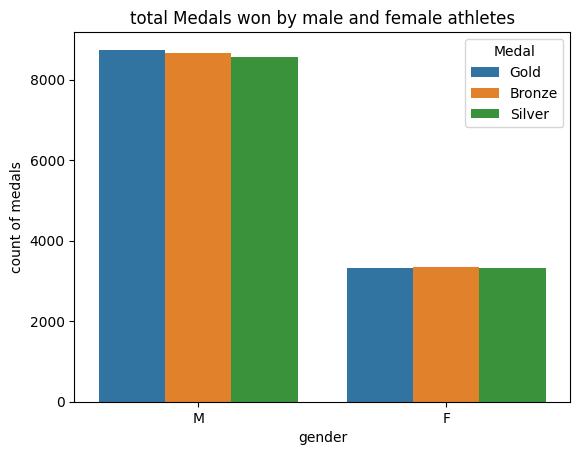

In [26]:
sns.countplot(data=Medal_winners_df,x='Sex',hue='Medal')
plt.title('total Medals won by male and female athletes')
plt.xlabel('gender')
plt.ylabel('count of medals')

plt.show()

Q9.Gender trend over years

In [31]:
medal_counts = df.groupby(['Year','Sex']).size().reset_index(name='medal_count')
medal_counts.head()

,Year,Sex,medal_count
0,1896.0,M,348
1,1900.0,F,32
2,1900.0,M,1764
3,1904.0,F,13
4,1904.0,M,1146


part 5 - spot analysis

Q10.Top sports


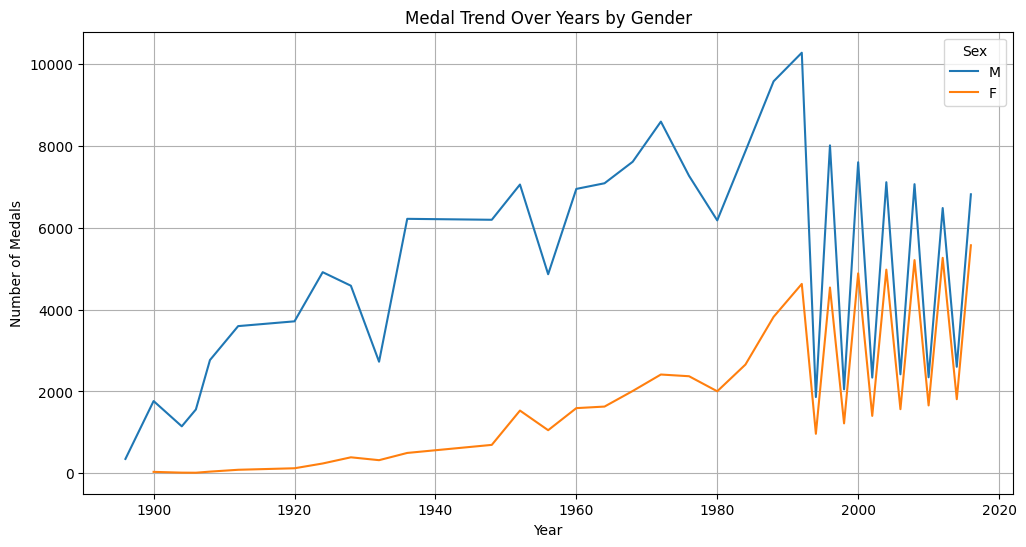

In [33]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=medal_counts, x='Year', y='medal_count', hue='Sex')
plt.title('Medal Trend Over Years by Gender')
plt.xlabel('Year')
plt.ylabel('Number of Medals')
plt.grid(True)
plt.show()

📌 PART 5 — Sport Analysis
Q10. Top Sports


In [34]:
top_sports = Medal_winners_df['Sport'].value_counts().head(10)
display(top_sports)

,count
Sport,
Athletics,3654
Swimming,2717
Rowing,2683
Gymnastics,2049
Fencing,1599
Football,1439
Ice Hockey,1414
Hockey,1366
Wrestling,1178


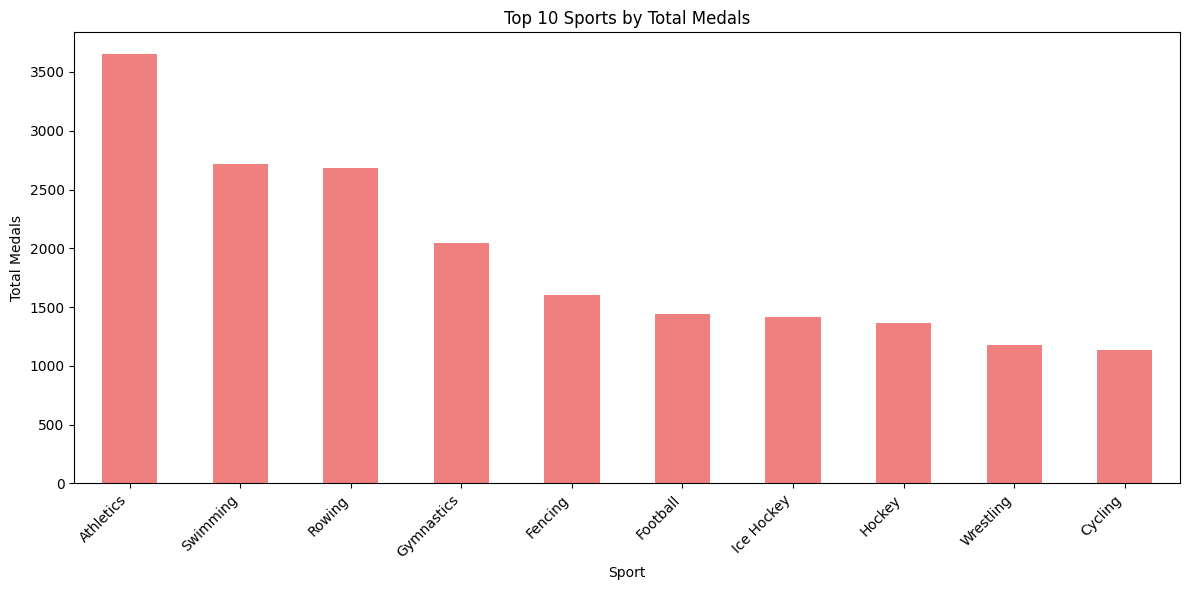

In [35]:
plt.figure(figsize=(12, 6))
top_sports.plot(kind='bar', color='lightcoral')
plt.title('Top 10 Sports by Total Medals')
plt.xlabel('Sport')
plt.ylabel('Total Medals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Q11. Gold Medal Sport


In [36]:
gold_medal_sports = gold['Sport'].value_counts()
display(gold_medal_sports.head())

,count
Sport,
Athletics,1230
Swimming,1002
Rowing,902
Gymnastics,718
Fencing,548


📌 PART 6 — Year-wise Analysis
Q12. Medal Trend Over Time


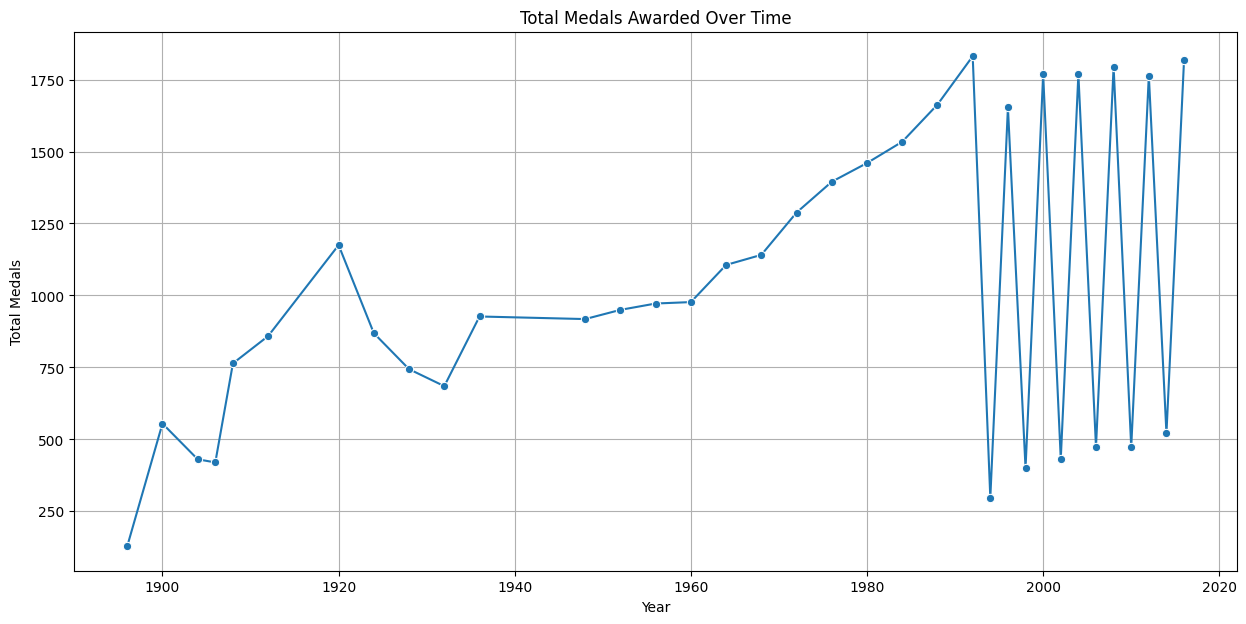

In [38]:
medals_per_year = Medal_winners_df.groupby('Year').size().reset_index(name='Total Medals')
plt.figure(figsize=(15, 7))
sns.lineplot(data=medals_per_year, x='Year', y='Total Medals', marker='o')
plt.title('Total Medals Awarded Over Time')
plt.xlabel('Year')
plt.ylabel('Total Medals')
plt.grid(True)
plt.show()

Q13. Best Olympic Year


In [48]:
best_year = medals_per_year.loc[medals_per_year['Total Medals'].idxmax()]
display(best_year)

,22
Year,1992.0
Total Medals,1831.0


📌 PART 7 — Age Analysis
Q14. Age Distribution


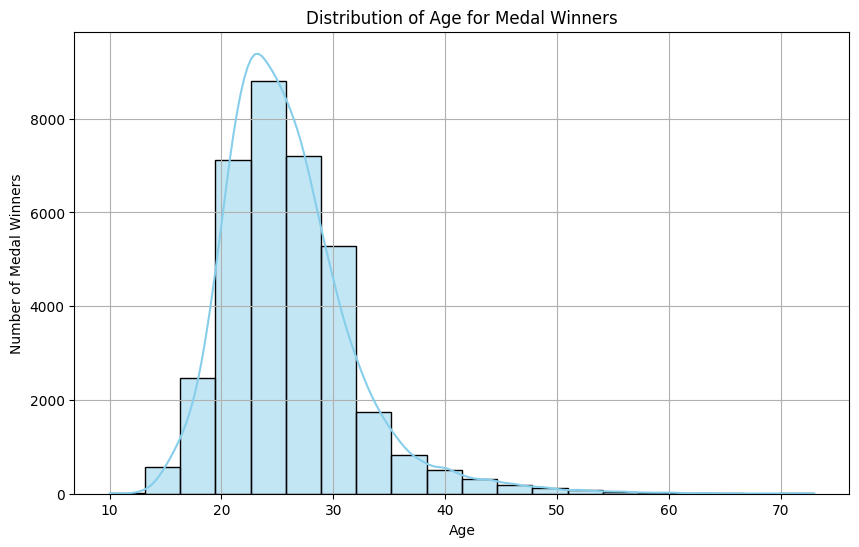

In [41]:
plt.figure(figsize=(10, 6))
sns.histplot(Medal_winners_df['Age'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Distribution of Age for Medal Winners')
plt.xlabel('Age')
plt.ylabel('Number of Medal Winners')
plt.grid(True)
plt.show()

From the histogram, it appears that the most common winning age range for medalists is approximately between **20 and 30 years old**, with a noticeable peak around the mid-20s.

Q15. Average Age by Medal Type


In [43]:
avg_age_by_medal = Medal_winners_df.groupby('Medal')['Age'].mean().reset_index()
display(avg_age_by_medal)

,Medal,Age
0,Bronze,25.902074
1,Gold,25.906690
2,Silver,26.027022


/tmp/ipykernel_176/4158389662.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_age_by_medal, x='Medal', y='Age', palette='viridis')


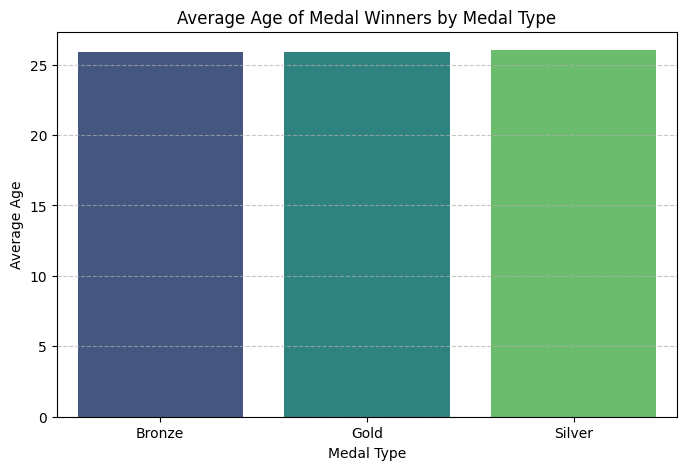

In [44]:
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_age_by_medal, x='Medal', y='Age', palette='viridis')
plt.title('Average Age of Medal Winners by Medal Type')
plt.xlabel('Medal Type')
plt.ylabel('Average Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

📌 PART 8 — Correlation & Numerical Insight
Q16. Correlation Matrix


In [46]:
numerical_cols = ['Age', 'Height', 'Weight']
correlation_matrix = Medal_winners_df[numerical_cols].corr()
display(correlation_matrix)

,Age,Height,Weight
Age,1.000000,0.092468,0.163300
Height,0.092468,1.000000,0.803412
Weight,0.163300,0.803412,1.000000


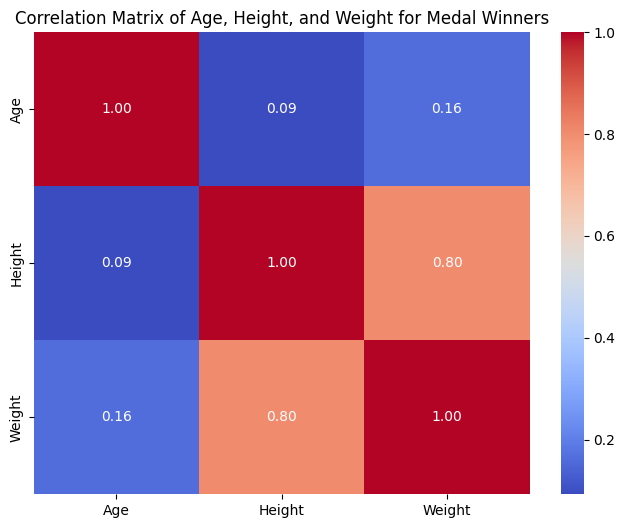

In [47]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Age, Height, and Weight for Medal Winners')
plt.show()

From the correlation matrix and the heatmap, the two variables that are most correlated are **Height** and **Weight**, with a correlation coefficient of approximately **0.80**.

📌 PART 9 — Mini Investigation (Open-Ended)
Q17. Country Performance


In [50]:
india_medals = Medal_winners_df[Medal_winners_df['NOC'] == 'IND']
total_medals_india = india_medals.shape[0]
gold_medals_india = india_medals[india_medals['Medal'] == 'Gold'].shape[0]

print(f"India's Total Medals: {total_medals_india}")
print(f"India's Gold Medals: {gold_medals_india}")

India's Total Medals: 195
India's Gold Medals: 136


Q18. Sport Deep Dive


#### **Sport Deep Dive: Athletics**

Top 5 Countries by Medals in Athletics:


,count
NOC,
USA,1006
GBR,317
URS,228
GER,145
JAM,138


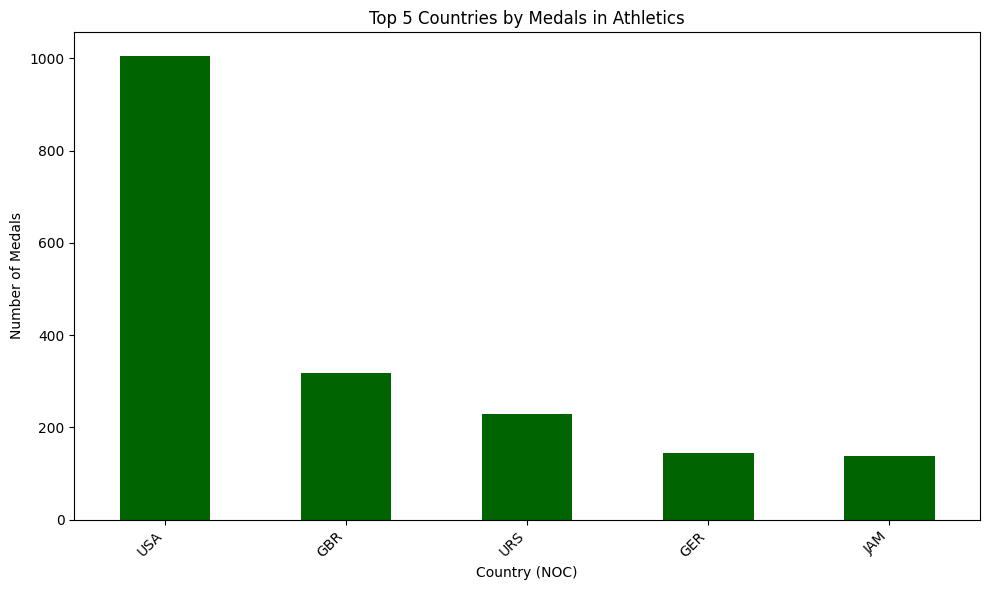

In [51]:
athletics_medals = Medal_winners_df[Medal_winners_df['Sport'] == 'Athletics']

# Which country dominates?
top_country_athletics = athletics_medals['NOC'].value_counts().head(5)
print("Top 5 Countries by Medals in Athletics:")
display(top_country_athletics)

plt.figure(figsize=(10, 6))
top_country_athletics.plot(kind='bar', color='darkgreen')
plt.title('Top 5 Countries by Medals in Athletics')
plt.xlabel('Country (NOC)')
plt.ylabel('Number of Medals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

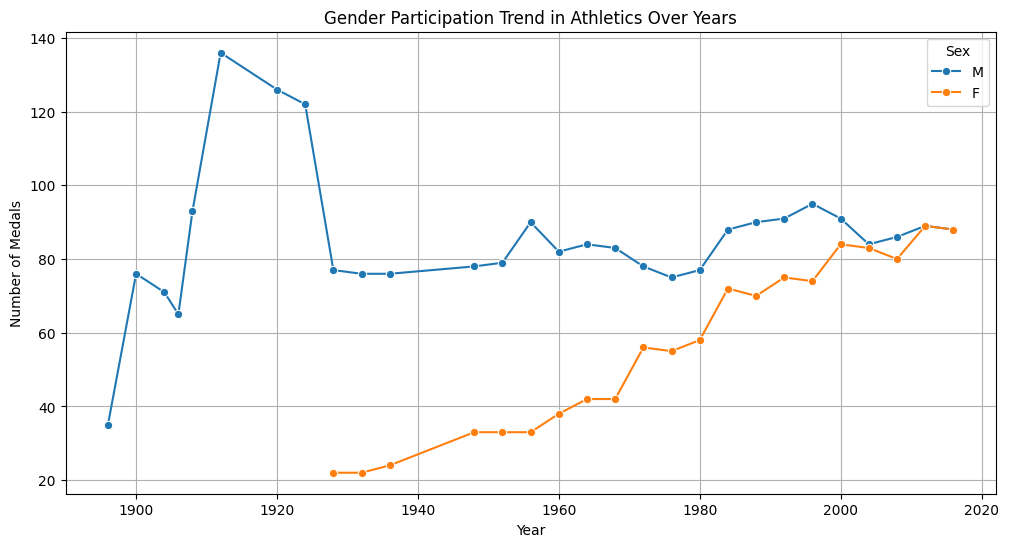

In [52]:
# Gender participation trend in Athletics
gender_trend_athletics = athletics_medals.groupby(['Year', 'Sex']).size().reset_index(name='Medal Count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=gender_trend_athletics, x='Year', y='Medal Count', hue='Sex', marker='o')
plt.title('Gender Participation Trend in Athletics Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Medals')
plt.grid(True)
plt.show()

Average Age of Medal Winners in Athletics: 25.02 years


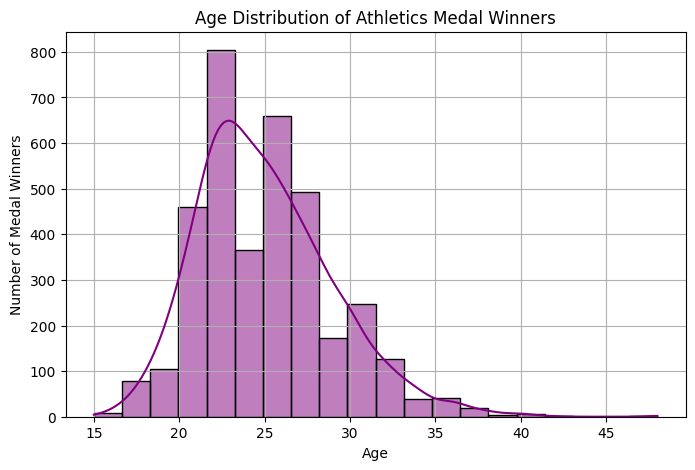

In [53]:
# Average age of winners in Athletics
avg_age_athletics = athletics_medals['Age'].mean()
print(f"Average Age of Medal Winners in Athletics: {avg_age_athletics:.2f} years")

plt.figure(figsize=(8, 5))
sns.histplot(athletics_medals['Age'].dropna(), bins=20, kde=True, color='purple')
plt.title('Age Distribution of Athletics Medal Winners')
plt.xlabel('Age')
plt.ylabel('Number of Medal Winners')
plt.grid(True)
plt.show()